In [1]:
import os
os.chdir('./proj2_data')
os.getcwd()

'/home/tako/Kasetsart/statistics/project2/proj2_data'

In [2]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

### Load and Split Data

In [3]:
data = pd.read_csv('articles_handout.csv', sep=",")
data.head()

,text,label
0,boothroyd calls for lords speaker betty boothr...,1
1,stuart joins norwich from addicks norwich have...,2
2,tories urge change at the top tory delegates...,1
3,celtic unhappy over bulgaria date martin o nei...,2
4,green fear for transport ballot the green part...,1


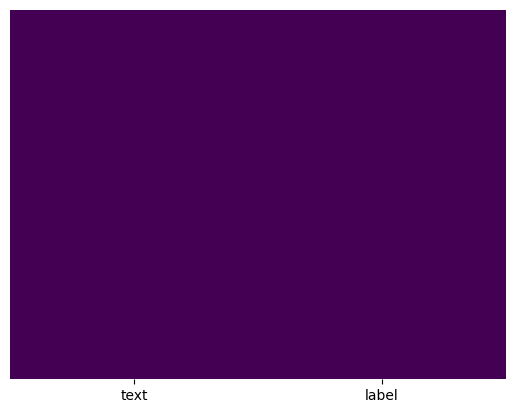

In [4]:
df=data.copy()
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')
plt.show()

In [5]:
null_percent = df.isnull().sum()/len(df)*100
null_percent

text     0.0
label    0.0
dtype: float64

In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(data['text'], data['label'], test_size=0.2, random_state=42)

In [7]:
print(X_train.shape)
print(X_test.shape)

(581,)
(146,)


### Functions

In [8]:
def evaluate_performance(y_true, y_pred, average_val='macro'):

    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average=average_val)
    recall = recall_score(y_true, y_pred, average=average_val)
    f1 = f1_score(y_true, y_pred, average=average_val)

    from sklearn.metrics import confusion_matrix
    confusion = confusion_matrix(y_true, y_pred)

    return accuracy, precision, recall, f1, confusion

### Text Preprocessing

In [9]:
import nltk
custom_dir = '../../.devenv/state/venv/nltk_data' 
nltk.download('punkt_tab', download_dir=custom_dir)
nltk.download('stopwords', download_dir=custom_dir)
nltk.download('wordnet', download_dir=custom_dir)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     ../../.devenv/state/venv/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     ../../.devenv/state/venv/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     ../../.devenv/state/venv/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [10]:
def preprocess_text(text):
    import re, string
    from nltk.tokenize import word_tokenize 
    from nltk.corpus import stopwords 
    from nltk.stem import WordNetLemmatizer    
    
    word_tokens = word_tokenize(text)
    word_tokens = [word.lower() for word in word_tokens] 
    word_tokens = [re.sub(r'[^\w\s]', '', token) for token in word_tokens if re.sub(r'[^\w\s]', '', token)]
    corpus_stop_words = set(stopwords.words('english')) 
    word_tokens = [word for word in word_tokens if not word in corpus_stop_words] 
    lemmatizer = WordNetLemmatizer()
    word_tokens = [lemmatizer.lemmatize(word) for word in word_tokens]
    return word_tokens

In [11]:
processed_X_train = [preprocess_text(word) for word in X_train]
processed_X_train

[['mp',
  'demand',
  'budget',
  'leak',
  'answer',
  'minister',
  'asked',
  'explain',
  'budget',
  'detail',
  'printed',
  'london',
  'newspaper',
  'half',
  'hour',
  'gordon',
  'brown',
  'made',
  'speech',
  'tory',
  'said',
  'large',
  'chunk',
  'budget',
  'appeared',
  'leaked',
  'describe',
  'serious',
  'breach',
  'treasury',
  'confidentiality',
  'lib',
  'dems',
  'called',
  'common',
  'leader',
  'peter',
  'hain',
  'make',
  'statement',
  'said',
  'chancellor',
  'resigned',
  'leak',
  'told',
  'would',
  'brought',
  'speaker',
  'michael',
  'martin',
  'attention',
  'common',
  'tory',
  'frontbencher',
  'andrew',
  'tyrie',
  'mp',
  'demanded',
  'immediate',
  'ministerial',
  'statement',
  'measure',
  'clearly',
  'least',
  'apparently',
  'leaked',
  'evening',
  'standard',
  'raising',
  'point',
  'order',
  'said',
  'latest',
  'long',
  'line',
  'discourtesy',
  'house',
  'well',
  'breach',
  'confidentiality',
  'said',
  'ho

In [12]:
processed_X_test = [preprocess_text(word) for word in X_test]
processed_X_test

[['zambia',
  'confident',
  'cautious',
  'zambia',
  'technical',
  'director',
  'kalusha',
  'bwalya',
  'confident',
  'cautious',
  'ahead',
  'cosafa',
  'cup',
  'final',
  'angola',
  'saturday',
  'lusaka',
  'bwalya',
  'said',
  'nothing',
  'short',
  'victory',
  'however',
  'bwalya',
  'warned',
  'side',
  'complacent',
  'want',
  'team',
  'comfortable',
  'sure',
  'victory',
  'going',
  'difficult',
  'game',
  'main',
  'aim',
  'game',
  'enjoy',
  'win',
  'zambia',
  'shown',
  'determination',
  'win',
  'final',
  'recalling',
  'nine',
  'foreignbased',
  'player',
  'however',
  '41',
  'yearold',
  'bwalya',
  'became',
  'oldest',
  'player',
  'appear',
  'competition',
  'played',
  'scored',
  'mauritius',
  'uncertain',
  'whether',
  'take',
  'field',
  'chipolopolo',
  'fan',
  'however',
  'cautious',
  'victory',
  'concert',
  'already',
  'scheduled',
  'match',
  'featuring',
  'country',
  'top',
  'musician',
  'side',
  'hoping',
  'win',


### Text Representation

In [13]:
# Convert nested list to word2vec vectors

In [14]:
selected_vector_size = 50

from gensim.models import Word2Vec
w2v_model = Word2Vec(sentences=processed_X_train,
                 vector_size=selected_vector_size,   # size of word embeddings
                 window=5,          # context window size
                 min_count=1,       # include all words
                 workers=4,         # number of CPU threads used to train the model in parallel.
                 sg=0,              # CBOW
                 seed=82
                )

In [15]:
def average_vectors(token_vector, vector_size=100):
    # token_vector = list of tokens or vocabs from one review
    # This function will:
    # 1) retrieve word vectors of all vocabs from models
    # 2) average word vectors to get one representative vector for each review

    # Get word vectors from CBOW model
    word_vectors = [w2v_model.wv[word] for word in token_vector if word in w2v_model.wv]
    # If no word exists in the model, return array of 100 zeros
    if len(word_vectors) == 0:
        return np.zeros(vector_size)
    # Convert word vectors to numpy arrays
    word_vectors_np = np.array(word_vectors)
    # Average numerical word vectors and return
    return word_vectors_np.mean(axis=0)

X_train_vectors = np.array([average_vectors(token_vector, selected_vector_size) for token_vector in processed_X_train])
X_test_vectors = np.array([average_vectors(token_vector, selected_vector_size) for token_vector in processed_X_test])

### Training Model and Evaluate Performance

In [16]:
# Classification model using X_train_vectors nd y_train as training dataset
# Use X_test_vectors as test dataset

In [17]:
selected_n = 100  # n_estimators  = number of decision trees used in random forest model, default value = 100
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators = selected_n, criterion = 'gini', random_state = 0)
clf.fit(X_train_vectors, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [18]:
y_predicted = clf.predict(X_test_vectors)
# Evalute performance
from sklearn.metrics import classification_report
print(classification_report(y_test,y_predicted))

              precision    recall  f1-score   support

           0       0.91      0.74      0.82        43
           1       0.96      0.98      0.97        54
           2       0.82      0.94      0.88        49

    accuracy                           0.90       146
   macro avg       0.90      0.89      0.89       146
weighted avg       0.90      0.90      0.90       146



In [19]:
print(y_predicted)

[2 2 1 1 2 0 1 0 1 2 0 2 0 0 1 0 0 2 1 1 2 0 0 1 1 0 2 1 2 0 2 2 2 1 0 1 1
 0 2 2 2 0 0 2 2 1 2 1 2 1 2 0 2 1 0 2 2 2 2 1 2 2 1 1 2 1 2 2 2 1 2 1 2 1
 1 0 2 2 1 2 2 0 1 0 0 1 2 1 1 1 0 2 2 2 0 2 0 2 0 2 1 1 2 1 2 1 1 0 2 0 2
 1 0 0 2 0 0 2 1 1 2 1 2 0 1 1 0 2 1 1 1 2 1 2 1 0 1 1 0 1 1 1 2 1 1 1]


In [20]:
accuracy, precision, recall, f1, confusion = evaluate_performance(y_test, y_predicted)
print('Accuracy:', accuracy)
print('Precision:', precision)
print('Recall:', recall)
print('F1 score:', f1)
print('Confusion:\n', confusion)

Accuracy: 0.8972602739726028
Precision: 0.8997835497835499
Recall: 0.8881476793990637
F1 score: 0.8897267869744935
Confusion:
 [[32  1 10]
 [ 1 53  0]
 [ 2  1 46]]


### Frequent words and similar words

In [21]:
from nltk.corpus import stopwords 
from collections import Counter
stop_words = set(stopwords.words('english')) 

# This code generates by Gemini
print("--- Top 10 Words by Class ---")

for label in sorted(df['label'].unique()):
    texts = df[df['label'] == label]['text']
    
    all_words = []
    for text in texts:
        # Tokenize the text: convert to lowercase and extract words with 3+ letters
        words = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
        # Remove stop words
        words = [w for w in words if w not in stop_words]
        all_words.extend(words)
    
    top_10 = Counter(all_words).most_common(10)
    
    print(f"\nLabel {label}:")
    for word, count in top_10:
        print(f"  {word}: {count}")

--- Top 10 Words by Class ---

Label 0:
  said: 430
  film: 408
  best: 358
  year: 232
  music: 230
  also: 205
  one: 198
  new: 178
  show: 161
  last: 159

Label 1:
  said: 1298
  would: 637
  labour: 438
  government: 426
  people: 383
  party: 366
  election: 328
  blair: 316
  new: 278
  could: 252

Label 2:
  said: 498
  year: 290
  first: 259
  world: 238
  game: 235
  time: 228
  england: 227
  win: 226
  two: 222
  last: 220


In [22]:
sentences = []
for text in df['text']:
    # Tokenize and lowercase (we keep stop words here because they help provide context)
    words = re.findall(r'\b[a-z]{3,}\b', str(text).lower())
    sentences.append(words)

print("\n--- Most Similar Words ---")

# Find similar words to "technology"
try:
    tech_similar = w2v_model.wv.most_similar('technology', topn=10)
    print("\nTop 10 similar to 'technology':")
    for word, score in tech_similar:
        print(f"  {word} (similarity: {score:.2f})")
except KeyError:
    print("\nThe word 'technology' does not appear enough times in these articles.")

# Find similar words to "finance"
try:
    finance_similar = w2v_model.wv.most_similar('finance', topn=10)
    print("\nTop 10 similar to 'finance':")
    for word, score in finance_similar:
        print(f"  {word} (similarity: {score:.2f})")
except KeyError:
    print("\nThe word 'finance' does not appear enough times in these articles.")


--- Most Similar Words ---

Top 10 similar to 'technology':
  keep (similarity: 1.00)
  written (similarity: 1.00)
  north (similarity: 1.00)
  become (similarity: 1.00)
  return (similarity: 1.00)
  judge (similarity: 1.00)
  area (similarity: 1.00)
  part (similarity: 1.00)
  led (similarity: 1.00)
  something (similarity: 1.00)

Top 10 similar to 'finance':
  bill (similarity: 1.00)
  street (similarity: 1.00)
  move (similarity: 1.00)
  former (similarity: 1.00)
  earlier (similarity: 1.00)
  choice (similarity: 1.00)
  may (similarity: 1.00)
  forward (similarity: 1.00)
  home (similarity: 1.00)
  new (similarity: 1.00)
